In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Problem 2: Jokes Recommendations

In this problem, we will build two recommender systems to recommend jokes to users. 
We'll be using the Jester Dataset (which is available [here](http://eigentaste.berkeley.edu/dataset/)).

The *jester.csv* file has data from 23,500 users who have rated 36 or more jokes. 
Ratings are real values ranging from -10.00 to +10.00.

In [19]:
# load the data
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Theory/master/Data/jester.csv'
ratings_matrix = pd.read_csv(url, index_col = 'user').T
ratings_matrix

user,0,1,2,3,4,5,6,7,8,9,...,23490,23491,23492,23493,23494,23495,23496,23497,23498,23499
joke 0,NaN,-4.37,NaN,0.34,NaN,NaN,3.50,-7.67,1.02,3.64,...,0.83,-0.58,NaN,-2.38,9.27,-9.95,-0.78,NaN,1.02,NaN
joke 1,8.11,-3.88,NaN,-6.55,NaN,NaN,2.28,7.14,6.07,1.60,...,4.27,-4.22,8.74,-1.12,8.79,4.85,1.31,NaN,2.77,NaN
joke 2,NaN,0.73,NaN,2.86,NaN,NaN,3.01,-6.31,6.65,-0.39,...,-2.23,2.04,NaN,-0.92,-5.58,-9.95,-2.09,NaN,7.09,NaN
joke 3,NaN,-3.20,NaN,NaN,NaN,NaN,-0.63,NaN,-0.87,3.74,...,-2.14,-6.02,NaN,-2.04,9.27,-8.25,-0.78,NaN,0.05,NaN
joke 4,-2.28,-6.41,0.73,-3.64,9.13,-1.46,4.95,-9.32,6.80,-6.36,...,-1.80,-9.76,1.17,-7.77,8.74,1.41,4.71,6.12,1.26,9.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
joke 95,-5.92,3.45,NaN,NaN,NaN,NaN,2.28,NaN,5.92,1.02,...,NaN,3.40,NaN,NaN,NaN,NaN,1.02,NaN,2.38,NaN
joke 96,NaN,3.20,NaN,NaN,NaN,NaN,5.05,1.60,-6.60,4.17,...,NaN,-0.53,NaN,NaN,NaN,NaN,2.57,NaN,2.62,NaN
joke 97,NaN,-0.53,NaN,NaN,NaN,NaN,4.51,NaN,0.24,-6.55,...,NaN,-7.28,NaN,NaN,NaN,NaN,1.02,NaN,2.57,NaN
joke 98,NaN,-0.53,NaN,NaN,NaN,NaN,4.08,NaN,9.08,-8.93,...,NaN,-7.52,NaN,NaN,NaN,NaN,-0.29,NaN,1.94,NaN


The *JokeText.csv* contains the text for each of the 100 jokes

In [20]:
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Theory/master/Data/JokeText.csv'
jokes = pd.read_csv(url, index_col = 'JokeId', squeeze = True)
jokes

JokeId
0     A man visits the doctor. The doctor says "I ha...
1     This couple had an excellent relationship goin...
2     Q. What's 200 feet long and has 4 teeth? \n\nA...
3     Q. What's the difference between a man and a t...
4     Q.\tWhat's O. J. Simpson's Internet address? \...
                            ...                        
95    Two attorneys went into a diner and ordered tw...
96    A teacher is explaining to her class how diffe...
97    Age and Womanhood\n\n1. Between the ages of 13...
98    A bus station is where a bus stops.\nA train s...
99    Q: Whats the difference between greeting a Que...
Name: JokeText, Length: 100, dtype: object

In [4]:
print(jokes[0])

A man visits the doctor. The doctor says "I have bad news for you.You have
cancer and Alzheimer's disease". 
The man replies "Well,thank God I don't have cancer!"



In [5]:
print(jokes[5])

Bill & Hillary are on a trip back to Arkansas. They're almost out of gas, so Bill pulls into a service station on the outskirts of
town. The attendant runs out of the station to serve them when Hillary realizes it's an old boyfriend from high school. She and
the attendant chat as he gases up their car and cleans the windows. Then they all say good-bye. 

As Bill pulls the car onto the road, he turns to Hillary and says, 'Now aren't you glad you married me and not him ? You could've
been the wife of a grease monkey !' 

To which Hillary replied, 'No, Bill. If I would have married him, you'd be pumping gas and he would be the President !' 



In [6]:
print(jokes[20])

What's the difference between a used tire and 365 used condoms?

One's a Goodyear, the other's a great year.



In [7]:
print(jokes[99])

Q: Whats the difference between greeting a Queen and greeting the
President of the United  States?

A: You only have to get on one knee to greet the queen.



In [8]:
print(jokes[39])

How many Irishmen does it take to change a lightbulb?

Two, one to hold the lightbulb and the other to drink until the room spins. 



## Part 1: create a 'fake user'

Run the following code

In [21]:
pd.Series(index = ratings_matrix.index, name='fake user').to_csv('fake_user.csv')

<ipython-input-21-2c2be1b2bd46>:1: DeprecationWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  pd.Series(index = ratings_matrix.index, name='fake user').to_csv('fake_user.csv')


Open the *fake_user.csv* file, and rate some jokes (you can find the text of each joke in the jokes dataframe). 
Your ratings must range from -10.00 to +10.00.

Then, run the following code

In [24]:
fake_user = pd.read_csv('fake_user.csv', index_col=0, squeeze=True)
fake_user[30:40]

joke 30    5.0
joke 31    2.0
joke 32   -2.0
joke 33   -7.0
joke 34    1.0
joke 35    8.0
joke 36    9.0
joke 37    1.0
joke 38   -7.0
joke 39   -2.0
Name: fake user, dtype: float64

## Part 2: user-based recommendations

Use the user-based recommendation model to find the top-5 recommendations.

In [25]:
user_mean = fake_user.mean()
user_mean

0.8

In [26]:
user_std = fake_user.std()
user_std

5.533734925185902

In [27]:
# user similarities
similarities = ratings_matrix.corrwith(fake_user)

In [28]:
# not rated movies
not_rated_jokes = fake_user[fake_user.isna()].index.to_list()
not_rated_jokes

['joke 0',
 'joke 1',
 'joke 2',
 'joke 3',
 'joke 4',
 'joke 5',
 'joke 6',
 'joke 7',
 'joke 8',
 'joke 9',
 'joke 10',
 'joke 11',
 'joke 12',
 'joke 13',
 'joke 14',
 'joke 15',
 'joke 16',
 'joke 17',
 'joke 18',
 'joke 19',
 'joke 20',
 'joke 21',
 'joke 22',
 'joke 23',
 'joke 24',
 'joke 25',
 'joke 26',
 'joke 27',
 'joke 28',
 'joke 29',
 'joke 40',
 'joke 41',
 'joke 42',
 'joke 43',
 'joke 44',
 'joke 45',
 'joke 46',
 'joke 47',
 'joke 48',
 'joke 49',
 'joke 50',
 'joke 51',
 'joke 52',
 'joke 53',
 'joke 54',
 'joke 55',
 'joke 56',
 'joke 57',
 'joke 58',
 'joke 59',
 'joke 60',
 'joke 61',
 'joke 62',
 'joke 63',
 'joke 64',
 'joke 65',
 'joke 66',
 'joke 67',
 'joke 68',
 'joke 69',
 'joke 70',
 'joke 71',
 'joke 72',
 'joke 73',
 'joke 74',
 'joke 75',
 'joke 76',
 'joke 77',
 'joke 78',
 'joke 79',
 'joke 80',
 'joke 81',
 'joke 82',
 'joke 83',
 'joke 84',
 'joke 85',
 'joke 86',
 'joke 87',
 'joke 88',
 'joke 89',
 'joke 90',
 'joke 91',
 'joke 92',
 'joke 93',
 '

In [29]:
z_scores = (ratings_matrix - ratings_matrix.mean())/ratings_matrix.std()

In [30]:
k = 20
for item in not_rated_jokes:
    # k nearest neighbors similarities
    knn_sim = similarities[ratings_matrix.loc[item].notna()].sort_values(ascending=False).head(k)

    # normalization factor
    total = knn_sim.abs().sum()
    
    # k nearest neighbors
    knn = knn_sim.index
    
    # k nearest neighbors z-scores
    knn_z_scores = z_scores.loc[item,knn]
    

    # prediction
    prediction = user_mean + user_std*knn_sim.dot(knn_z_scores)/total
    fake_user.loc[item] = prediction

In [31]:
# top 5 recommendations
top_five= fake_user.loc[not_rated_jokes].sort_values(ascending=False).head(5)
top_five

joke 49    4.993956
joke 26    4.503549
joke 88    3.795473
joke 61    3.337589
joke 86    3.323804
Name: fake user, dtype: float64

## Part 3: matrix-factorization-based recommendations

Use the matrix factorization recommendation model to find the top-5 recommendations.

In [32]:
# add fake user to the ratings matrix
ratings_matrix['user'] = pd.read_csv('fake_user.csv', index_col=0, squeeze=True)
# transpose the ratings_matrix
ratings_matrix = ratings_matrix.T
ratings_matrix

,joke 0,joke 1,joke 2,joke 3,joke 4,joke 5,joke 6,joke 7,joke 8,joke 9,...,joke 90,joke 91,joke 92,joke 93,joke 94,joke 95,joke 96,joke 97,joke 98,joke 99
user,,,,,,,,,,,,,,,,,,,,,
0,NaN,8.11,NaN,NaN,-2.28,-4.22,5.49,-2.62,NaN,-2.28,...,NaN,NaN,NaN,NaN,NaN,-5.92,NaN,NaN,NaN,NaN
1,-4.37,-3.88,0.73,-3.20,-6.41,1.17,7.82,-4.76,-6.41,0.73,...,5.73,-6.70,1.99,2.62,-0.49,3.45,3.20,-0.53,-0.53,-2.96
2,NaN,NaN,NaN,NaN,0.73,NaN,5.53,3.25,NaN,NaN,...,NaN,NaN,NaN,NaN,3.16,NaN,NaN,NaN,NaN,NaN
3,0.34,-6.55,2.86,NaN,-3.64,1.12,5.34,2.33,NaN,2.33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,9.13,NaN,-9.32,-2.04,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23496,-0.78,1.31,-2.09,-0.78,4.71,0.19,3.06,-1.31,-9.76,9.13,...,0.29,-0.92,0.53,2.14,2.48,1.02,2.57,1.02,-0.29,0.78
23497,NaN,NaN,NaN,NaN,6.12,NaN,5.78,-5.53,NaN,7.72,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23498,1.02,2.77,7.09,0.05,1.26,1.41,2.62,0.49,5.19,6.55,...,7.82,1.07,4.27,3.35,0.63,2.38,2.62,2.57,1.94,3.98


In [33]:
def matrix_factorization(R, k, learning_rate, n_epochs):
    m, n = R.shape
    
    # number of nonzero ratings
    n_zero_ratings = np.sum(~np.isnan(R))
    
    # initialization
    U = np.random.randn(m,k)
    V = np.random.randn(n,k)
    
    mean_error = np.zeros(n_epochs)
    
    # gradient descent steps
    for i in range(n_epochs):
        
        # error matrix
        E = R-U.dot(V.T)
        E[np.isnan(E)]=0

        # update U and V
        U,V = U + learning_rate*E.dot(V), V + learning_rate*E.T.dot(U)
        
        # compute mean_error
        error_squared = np.sum(E**2)
        mean_error[i] = np.sqrt(error_squared/(n_zero_ratings))
        
    return U, V, mean_error

In [34]:
R = ratings_matrix.to_numpy()

In [44]:
U, V, mean_error = matrix_factorization(R, 
                                        k = 20, 
                                        learning_rate = .00005, 
                                        n_epochs = 50)

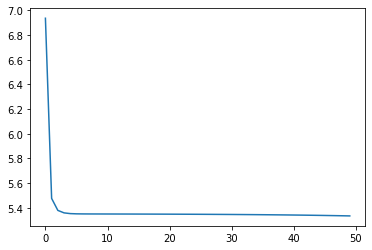

In [45]:
plt.plot(mean_error)

In [47]:
# predictions
R_pred = U.dot(V.T)
user_pred = pd.Series(R_pred[-1,:]) 
user_pred

0     0.305517
1     0.555663
2     0.462146
3     0.174330
4     0.262776
        ...   
95    0.411721
96   -0.211940
97    0.718507
98    0.011126
99    0.544882
Length: 100, dtype: float64

In [49]:
top_five = user_pred.sort_values(ascending=False).head(5)
top_five

52    0.888740
80    0.834510
30    0.823135
64    0.818217
68    0.738241
dtype: float64